# CAPTCHA OCR

Распознавание CAPTCHA с помощью FCNN и Bi-LSTM без предобученных моделей.

## 1. Data preparation

Метки извлекаются из имен файлов. Изображения загружаются через Pillow и преобразуются в тензоры. Итоговая test-выборка сохраняет 20% данных, а остальные примеры делятся на train и validation: 70/10/20 с фиксированным seed. Только для train применяются умеренные геометрические и цветовые аугментации, тонкие линии и локальный шум.

In [1]:
from pathlib import Path
import random

import numpy as np
import torch
from IPython.display import display
from PIL import Image
from torch import nn

from src.data import (
    CaptchaDataset,
    build_vocabulary,
    collect_image_paths,
    create_dataloaders,
    create_train_transform,
    split_dataset,
)
from src.model import CaptchaOCR, count_parameters
from src.training import evaluate, fit

SEED = 42
DATA_DIR = Path("data/samples")
BATCH_SIZE = 64
EPOCHS = 80
EARLY_STOPPING_PATIENCE = 7

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA runtime: {torch.version.cuda}")

PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
CUDA runtime: 12.8


In [2]:
image_paths = collect_image_paths(DATA_DIR)
labels, alphabet, char_to_idx, idx_to_char, captcha_length = build_vocabulary(image_paths)

dataset = CaptchaDataset(image_paths, char_to_idx)
augmented_dataset = CaptchaDataset(
    image_paths,
    char_to_idx,
    transform=create_train_transform(),
)
train_dataset, validation_dataset, test_dataset = split_dataset(
    dataset,
    train_dataset=augmented_dataset,
    train_fraction=0.7,
    validation_fraction=0.1,
    seed=SEED,
)
train_loader, validation_loader, test_loader = create_dataloaders(
    train_dataset,
    validation_dataset,
    test_dataset,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=device,
)

print(f"Images: {len(dataset)}")
print(
    f"Train/validation/test: {len(train_dataset)}/"
    f"{len(validation_dataset)}/{len(test_dataset)}"
)
print(f"CAPTCHA length: {captcha_length}")
print(f"Alphabet ({len(alphabet)}): {''.join(alphabet)}")

Images: 1070
Train/validation/test: 749/107/214
CAPTCHA length: 5
Alphabet (19): 2345678bcdefgmnpwxy


Path: data\samples\226md.png
Label: 226md
Encoded target: [0, 0, 4, 13, 9]
Tensor shape: (3, 50, 200)


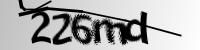

In [3]:
sample_image, sample_target, sample_label, sample_path = dataset[0]
print(f"Path: {sample_path}")
print(f"Label: {sample_label}")
print(f"Encoded target: {sample_target.tolist()}")
print(f"Tensor shape: {tuple(sample_image.shape)}")
with Image.open(sample_path) as image:
    display(image.convert("RGB"))

## 2. Model creation and training

FCNN извлекает визуальные признаки и сворачивает только вертикальное измерение. Полная горизонтальная карта из 25 шагов поступает в двухслойную Bi-LSTM, которая учитывает контекст слева и справа. После Bi-LSTM temporal pooling формирует пять выходных позиций, а линейный слой выдает logits по алфавиту. Оптимизируется Cross-Entropy loss.

In [4]:
model = CaptchaOCR(
    num_classes=len(alphabet),
    captcha_length=captcha_length,
    hidden_size=128,
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

print(model)
print(f"Trainable parameters: {count_parameters(model):,}")

CaptchaOCR(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Sequential(
      (0): Co

In [5]:
images, targets, _, _ = next(iter(train_loader))
with torch.no_grad():
    sequence_features = model.extract_sequence(images[:2].to(device))
    logits = model(images[:2].to(device))
print(f"Input shape: {tuple(images[:2].shape)}")
print(f"Bi-LSTM input shape: {tuple(sequence_features.shape)}")
print(f"Logits shape: {tuple(logits.shape)}")
assert sequence_features.shape[1] > captcha_length
assert logits.shape == (2, captcha_length, len(alphabet))

Input shape: (2, 3, 50, 200)
Bi-LSTM input shape: (2, 25, 192)
Logits shape: (2, 5, 19)


In [6]:
history = fit(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    idx_to_char,
    epochs=EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    use_amp=True,
)

Epoch 01/80: train_loss=2.9271, val_loss=2.9258, val_CER=0.9047, val_accuracy=0.0000, lr=1.00e-03


Epoch 02/80: train_loss=2.8184, val_loss=2.9600, val_CER=0.9065, val_accuracy=0.0000, lr=1.00e-03


Epoch 03/80: train_loss=2.6112, val_loss=3.0663, val_CER=0.9421, val_accuracy=0.0000, lr=1.00e-03


Epoch 04/80: train_loss=2.3280, val_loss=2.6575, val_CER=0.8299, val_accuracy=0.0000, lr=1.00e-03


Epoch 05/80: train_loss=2.0253, val_loss=2.0542, val_CER=0.7570, val_accuracy=0.0000, lr=1.00e-03


...

Epoch 44/80: train_loss=0.0235, val_loss=0.0823, val_CER=0.0243, val_accuracy=0.8785, lr=6.25e-05


Epoch 45/80: train_loss=0.0265, val_loss=0.0856, val_CER=0.0299, val_accuracy=0.8598, lr=6.25e-05


Epoch 46/80: train_loss=0.0215, val_loss=0.0841, val_CER=0.0299, val_accuracy=0.8505, lr=6.25e-05


Epoch 47/80: train_loss=0.0226, val_loss=0.0853, val_CER=0.0299, val_accuracy=0.8598, lr=3.13e-05


Epoch 48/80: train_loss=0.0223, val_loss=0.0864, val_CER=0.0280, val_accuracy=0.8692, lr=3.13e-05
Early stopping after 48 epochs; best validation CER=0.0187.


## 3. CER evaluation

Character Error Rate вычисляется как суммарное расстояние Левенштейна между истинными и предсказанными строками, деленное на общее число символов в истинных строках. Чем ближе CER к нулю, тем лучше.

In [7]:
test_metrics = evaluate(
    model,
    test_loader,
    criterion,
    device,
    idx_to_char,
    use_amp=True,
)
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"CER: {test_metrics['cer']:.4f}")
print(f"Exact CAPTCHA accuracy: {test_metrics['exact_accuracy']:.4f}")

Test loss: 0.0748


CER: 0.0159
Exact CAPTCHA accuracy: 0.9252


## 4. Error analysis

Ниже показаны примеры с наибольшим числом ошибочных символов.

True: b5nmm | Predicted: b5mmn | errors: 2 | sample CER: 0.40


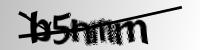

True: e2mg2 | Predicted: c2mg2 | errors: 1 | sample CER: 0.20


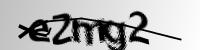

True: 7fmcy | Predicted: 7fncy | errors: 1 | sample CER: 0.20


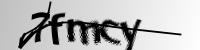

True: mdyp7 | Predicted: ndyp7 | errors: 1 | sample CER: 0.20


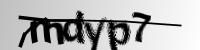

True: mfc35 | Predicted: nfc35 | errors: 1 | sample CER: 0.20


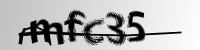

In [8]:
worst_predictions = sorted(
    test_metrics["records"],
    key=lambda record: record["distance"],
    reverse=True,
)[:5]

for record in worst_predictions:
    print(
        f"True: {record['reference']} | "
        f"Predicted: {record['prediction']} | "
        f"errors: {record['distance']} | "
        f"sample CER: {record['sample_cer']:.2f}"
    )
    with Image.open(record["path"]) as image:
        display(image.convert("RGB"))

Возможные причины ошибок:

- линии и шум пересекают штрихи символов;
- похожие символы имеют близкую форму;
- небольшой датасет не покрывает все варианты искажений;
- адаптивное разбиение на пять позиций предполагает примерно равномерное расположение символов.

Возможные улучшения:

- увеличить число примеров и сбалансировать частоты символов;
- подобрать глубину FCNN, размер hidden state и learning rate;

## 5. Conclusions

In [9]:
best_epoch = min(history, key=lambda row: row["validation_cer"])
print(
    "Реализован полный OCR pipeline: Pillow Dataset, воспроизводимый split, "
    "FCNN + Bi-LSTM и CrossEntropyLoss."
)
print(
    f"Лучший validation CER: {best_epoch['validation_cer']:.4f} "
    f"на эпохе {best_epoch['epoch']}."
)
print(
    f"Итоговая точность полного совпадения CAPTCHA: "
    f"{test_metrics['exact_accuracy']:.2%}."
)

Реализован полный OCR pipeline: Pillow Dataset, воспроизводимый split, FCNN + Bi-LSTM и CrossEntropyLoss.
Лучший validation CER: 0.0187 на эпохе 41.
Итоговая точность полного совпадения CAPTCHA: 92.52%.
